In [16]:
#datacreation and saving

import pandas as pd
import numpy as np

np.random.seed(42)

# 640 non-purchasers
age0 = np.random.randint(18, 35, 640)
salary0 = np.random.randint(20000, 60000, 640)
exp0 = np.random.randint(0, 5, 640)

# 160 purchasers
age1 = np.random.randint(30, 60, 160)
salary1 = np.random.randint(70000, 120000, 160)
exp1 = np.random.randint(5, 20, 160)

df0 = pd.DataFrame({
    "Age": age0,
    "Salary": salary0,
    "Experience": exp0,
    "Purchased": 0
})

df1 = pd.DataFrame({
    "Age": age1,
    "Salary": salary1,
    "Experience": exp1,
    "Purchased": 1
})

df = pd.concat([df0, df1], ignore_index=True)

# Shuffle rows
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(df["Purchased"].value_counts())

df.to_csv("dataset.csv")




Purchased
0    640
1    160
Name: count, dtype: int64


In [62]:
#step 2

df=pd.read_csv("dataset.csv")
df["Salary_per_Experience"]=df["Salary"]/(df["Experience"]+1)
df["Age_bucket"]=pd.cut(df['Age'],bins=[18,25,35,45,float("inf")],
                        labels=['18-25','26-35','36-45','46+'],
                        include_lowest=True)

print(df.head())

   Unnamed: 0  Age  Salary  Experience  Purchased  Salary_per_Experience  \
0           0   31  117684           6          1                16812.0   
1           1   31  100620          17          1                 5590.0   
2           2   30   33234           0          0                33234.0   
3           3   22   23430           1          0                11715.0   
4           4   26   30954           0          0                30954.0   

  Age_bucket  
0      26-35  
1      26-35  
2      26-35  
3      18-25  
4      26-35  


In [19]:
dff=pd.read_csv("dataset.csv")
dff["Salary_per_Experience"]=dff["Salary"]/(dff["Experience"]+1)
dff["Age_bucket"]=pd.cut(dff['Age'],bins=[18,25,35,45,float("inf")],
                        labels=['18-25','26-35','36-45','46+'],
                        include_lowest=True)

print(dff.head())

   Unnamed: 0  Age  Salary  Experience  Purchased  Salary_per_Experience  \
0           0   31  117684           6          1                16812.0   
1           1   31  100620          17          1                 5590.0   
2           2   30   33234           0          0                33234.0   
3           3   22   23430           1          0                11715.0   
4           4   26   30954           0          0                30954.0   

  Age_bucket  
0      26-35  
1      26-35  
2      26-35  
3      18-25  
4      26-35  


In [ ]:
from sklearn.preprocessing import OneHotEncoder,LabelEncoder

Oe = OneHotEncoder(sparse_output=False)

encoded = Oe.fit_transform(df[['Age_bucket']])

encoded_df = pd.DataFrame(
    encoded,
    columns=Oe.get_feature_names_out(['Age_bucket'])
)
df = pd.concat([df.drop('Age_bucket', axis=1), encoded_df], axis=1)
print(df.head())



   Unnamed: 0  Age  Salary  Experience  Purchased  Salary_per_Experience  \
0           0   31  117684           6          1                16812.0   
1           1   31  100620          17          1                 5590.0   
2           2   30   33234           0          0                33234.0   
3           3   22   23430           1          0                11715.0   
4           4   26   30954           0          0                30954.0   

   Age_bucket_18-25  Age_bucket_26-35  Age_bucket_36-45  Age_bucket_46+  
0               0.0               1.0               0.0             0.0  
1               0.0               1.0               0.0             0.0  
2               0.0               1.0               0.0             0.0  
3               1.0               0.0               0.0             0.0  
4               0.0               1.0               0.0             0.0  


In [75]:
le=LabelEncoder()
dff['Age_bucket']= le.fit_transform(dff['Age_bucket'])
print(dff.head())


   Unnamed: 0  Age  Salary  Experience  Purchased  Salary_per_Experience  \
0           0   31  117684           6          1                16812.0   
1           1   31  100620          17          1                 5590.0   
2           2   30   33234           0          0                33234.0   
3           3   22   23430           1          0                11715.0   
4           4   26   30954           0          0                30954.0   

   Age_bucket  
0           1  
1           1  
2           1  
3           0  
4           1  


In [21]:
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split
x=df.drop(['Purchased'],axis=1)
y=df['Purchased']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
x_trained=scaler.fit_transform(x_train)
x_tested=scaler.transform(x_test)

In [27]:
import tensorflow as tf

model=tf.keras.Sequential([
    tf.keras.layers.Input(shape=(9,)),
    tf.keras.layers.Dense(32,activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(32,activation='relu'),
    tf.keras.layers.Dense(1,activation='sigmoid')
])

model.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])
history=model.fit(x_trained,y_train,validation_split=0.2,epochs=10,batch_size=32,verbose=0)
loss,acc=model.evaluate(x_tested,y_test)
print(loss*100)
print(acc*100)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0283 
2.8262946754693985
100.0


In [42]:
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split
x=dff.drop(['Purchased'],axis=1)
y=dff['Purchased']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
x_trained=scaler.fit_transform(x_train)
x_tested=scaler.transform(x_test)
import tensorflow as tf

model=tf.keras.Sequential([
    tf.keras.layers.Input(shape=(6,)),
    tf.keras.layers.Dense(32,activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(32,activation='relu'),
    tf.keras.layers.Dense(1,activation='sigmoid')
])

model.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])
history=model.fit(x_trained,y_train,validation_split=0.2,epochs=10,batch_size=32,verbose=0)
loss,acc=model.evaluate(x_tested,y_test)
print(loss*100)
print(acc*100)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 1.0000 - loss: 0.0127
1.2735694646835327
100.0


In [65]:

q1 = df["Salary"].quantile(0.25)
q3 = df["Salary"].quantile(0.75)

iqr = q3 - q1

lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

print("q1:", q1)
print("q3:", q3)
print("iqr:", iqr)
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)


q1: 31945.0
q3: 57475.5
iqr: 25530.5
Lower Limit: -6350.75
Upper Limit: 95771.25


In [69]:
df= df[
    (df["Salary"] >= lower_limit) &
    (df["Salary"] <= upper_limit)
]
df=pd.DataFrame(df)
print(df.head())

   Unnamed: 0  Age  Salary  Experience  Purchased  Salary_per_Experience  \
2           2   30   33234           0          0               33234.00   
3           3   22   23430           1          0               11715.00   
4           4   26   30954           0          0               30954.00   
5           5   33   26183           4          0                5236.60   
6           6   18   33221           3          0                8305.25   

   Age_bucket_18-25  Age_bucket_26-35  Age_bucket_36-45  Age_bucket_46+  
2               0.0               1.0               0.0             0.0  
3               1.0               0.0               0.0             0.0  
4               0.0               1.0               0.0             0.0  
5               0.0               1.0               0.0             0.0  
6               1.0               0.0               0.0             0.0  


In [70]:
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split
x=df.drop(['Purchased'],axis=1)
y=df['Purchased']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
x_trained=scaler.fit_transform(x_train)
x_tested=scaler.transform(x_test)
import tensorflow as tf

model=tf.keras.Sequential([
    tf.keras.layers.Input(shape=(9,)),
    tf.keras.layers.Dense(32,activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(32,activation='relu'),
    tf.keras.layers.Dense(1,activation='sigmoid')
])

model.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])
history=model.fit(x_trained,y_train,validation_split=0.2,epochs=10,batch_size=32,verbose=0)
loss,acc=model.evaluate(x_tested,y_test)
print(loss*100)
print(acc*100)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 0.0274
2.7381256222724915
100.0


### above we computed with standard scaler and by removing outliers in salary column . now we are doing Q7 by using minmax

In [71]:
from sklearn.preprocessing import MinMaxScaler,LabelEncoder
from sklearn.model_selection import train_test_split
x=df.drop(['Purchased'],axis=1)
y=df['Purchased']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
scaler=MinMaxScaler()
x_trained=scaler.fit_transform(x_train)
x_tested=scaler.transform(x_test)
import tensorflow as tf
model=tf.keras.Sequential([
    tf.keras.layers.Input(shape=(9,)),
    tf.keras.layers.Dense(32,activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(32,activation='relu'),
    tf.keras.layers.Dense(1,activation='sigmoid')
])

model.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])
history=model.fit(x_trained,y_train,validation_split=0.2,epochs=10,batch_size=32,verbose=0)
loss,acc=model.evaluate(x_tested,y_test)
print(loss*100)
print(acc*100)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9510 - loss: 0.1582
15.821671485900879
95.10489702224731


### q5

In [ ]:
import seaborn as sns

features=df.drop(columns=['Purchased'])

matrix=features.corr()
print(matrix)

                       Unnamed: 0       Age    Salary  Experience  \
Unnamed: 0               1.000000  0.041461 -0.019594    0.005074   
Age                      0.041461  1.000000  0.553095    0.628739   
Salary                  -0.019594  0.553095  1.000000    0.652095   
Experience               0.005074  0.628739  0.652095    1.000000   
Salary_per_Experience   -0.024288 -0.180130  0.050067   -0.527667   
Age_bucket_18-25        -0.033351 -0.710590 -0.239661   -0.260417   
Age_bucket_26-35         0.045017  0.289344 -0.129045   -0.155657   
Age_bucket_36-45        -0.066181  0.262465  0.408166    0.392368   
Age_bucket_46+           0.023465  0.732032  0.510770    0.627862   

                       Salary_per_Experience  Age_bucket_18-25  \
Unnamed: 0                         -0.024288         -0.033351   
Age                                -0.180130         -0.710590   
Salary                              0.050067         -0.239661   
Experience                         -0.527667 

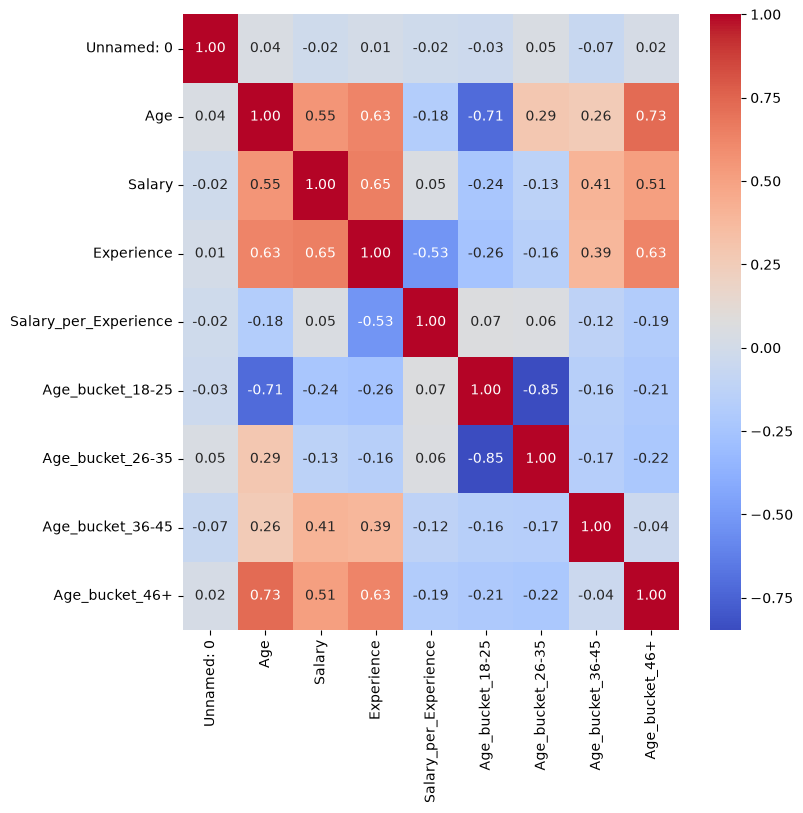

In [83]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,8))
sns.heatmap(matrix,annot=True,cmap='coolwarm',fmt='.2f')
plt.show()

# q9

In [89]:
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split
x=df.drop(['Purchased'],axis=1)
y=df['Purchased']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.15,random_state=42,stratify=y)
scaler=StandardScaler()
x_trained=scaler.fit_transform(x_train)
x_tested=scaler.transform(x_test)
import tensorflow as tf

model=tf.keras.Sequential([
    tf.keras.layers.Input(shape=(9,)),
    tf.keras.layers.Dense(32,activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(32,activation='relu'),
    tf.keras.layers.Dense(1,activation='sigmoid')
])

model.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])
history=model.fit(x_trained,y_train,validation_split=0.15,epochs=10,batch_size=32,verbose=0)
loss,acc=model.evaluate(x_tested,y_test)
print(loss*100)
print(acc*100)
print(model.summary())

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9907 - loss: 0.0530
5.302248150110245
99.0740716457367


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_75 (Dense)                │ (None, 32)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_45          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_76 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_46          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_77 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_47          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_78 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_79 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,397 (107.02 KB)

 Trainable params: 9,025 (35.25 KB)

 Non-trainable params: 320 (1.25 KB)

 Optimizer params: 18,052 (70.52 KB)

None


In [91]:
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split
x=df.drop(['Purchased'],axis=1)
y=df['Purchased']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.15,random_state=42,stratify=y)
scaler=StandardScaler()
x_trained=scaler.fit_transform(x_train)
x_tested=scaler.transform(x_test)
import tensorflow as tf
model=tf.keras.Sequential([
    tf.keras.layers.Input(shape=(9,)),
    tf.keras.layers.Dense(32,activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(32,activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1,activation='sigmoid')
])

model.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])
history=model.fit(x_trained,y_train,validation_split=0.15,epochs=10,batch_size=32,verbose=0)
loss,acc=model.evaluate(x_tested,y_test)
print(loss*100)
print(acc*100)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9907 - loss: 0.1219
12.18574121594429
99.0740716457367


## q12 after adding drop out after each hidden layer i did observed a small change in accuracy and the loss is more in this version